# Docling PDF→DOCX Benchmark

**Purpose:** Evaluate whether `docling` (MIT) can replace `pdf2docx` (AGPL) for converting 60-page PDFs to DOCX within the 90-second Celery task timeout.

**Library:** [docling](https://github.com/docling-project/docling) 2.77.0 · pypdfium2 (Apache 2.0) · htmldocx + python-docx for DOCX output

**Key difference from pdf2docx:** docling has **no native DOCX export**. The pipeline is:
1. PDF → docling (ML-based layout analysis via pypdfium2)
2. DoclingDocument → HTML export
3. HTML → DOCX via htmldocx + python-docx

**Test PDFs generated with:** reportlab (BSD) — no PyMuPDF/AGPL dependency needed

---

In [1]:
import io
import os
import time
import zipfile

from docling.document_converter import DocumentConverter
from docx import Document
from htmldocx import HtmlToDocx
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import SimpleDocTemplate, Paragraph, Table, TableStyle, Spacer, Image
from PIL import Image as PILImage

PAGES = 60
OUTPUT_DIR = "/tmp/docling_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

styles = getSampleStyleSheet()
results = []

# Warm up docling (downloads/loads ML models on first call)
print("Warming up docling models (first-run model load)...")
warmup_doc = SimpleDocTemplate("/tmp/_warmup.pdf", pagesize=letter)
warmup_doc.build([Paragraph("warmup", styles["Normal"])])
converter = DocumentConverter()
_ = converter.convert("/tmp/_warmup.pdf")
print("Models loaded. Ready to benchmark.\n")


def run_conversion(name, pdf_path):
    """Full pipeline: PDF → docling → HTML → DOCX. Returns timing breakdown."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    docx_path = pdf_path.replace(".pdf", ".docx")

    # Phase 1: docling parse
    t0 = time.time()
    result = converter.convert(pdf_path)
    t_parse = time.time() - t0

    # Phase 2: export to HTML
    t1 = time.time()
    html = result.document.export_to_html()
    t_html = time.time() - t1

    # Phase 3: HTML → DOCX
    t2 = time.time()
    doc = Document()
    HtmlToDocx().add_html_to_document(html, doc)
    doc.save(docx_path)
    t_docx = time.time() - t2

    total = t_parse + t_html + t_docx
    docx_kb = os.path.getsize(docx_path) / 1024
    verdict = "Safe" if total < 60 else ("At risk" if total < 90 else "Exceeds 90s")

    # Quality: count paragraphs, tables, cells, images
    doc_check = Document(docx_path)
    n_paras = len([p for p in doc_check.paragraphs if p.text.strip()])
    n_tables = len(doc_check.tables)
    n_cells = sum(len(r.cells) for t in doc_check.tables for r in t.rows)
    with zipfile.ZipFile(docx_path) as z:
        n_images = len([n for n in z.namelist() if n.startswith("word/media/")])

    results.append({
        "scenario": name, "pdf_kb": pdf_kb, "docx_kb": docx_kb,
        "t_parse": t_parse, "t_html": t_html, "t_docx": t_docx, "total_s": total,
        "per_page_s": total / PAGES, "verdict": verdict,
        "paras": n_paras, "tables": n_tables, "cells": n_cells, "images": n_images,
    })

    print(f"  PDF size:      {pdf_kb:,.0f} KB")
    print(f"  DOCX size:     {docx_kb:,.0f} KB")
    print(f"  Parse time:    {t_parse:.2f}s")
    print(f"  HTML export:   {t_html:.2f}s")
    print(f"  HTML→DOCX:     {t_docx:.2f}s")
    print(f"  Total time:    {total:.2f}s  ({total/PAGES:.3f}s/page)")
    print(f"  Verdict:       {verdict}")
    print(f"  Quality:       {n_paras} paragraphs, {n_tables} tables, {n_cells} cells, {n_images} images")
    return total

print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

Warming up docling models (first-run model load)...


Models loaded. Ready to benchmark.

Generating 60-page test PDFs in /tmp/docling_bench/


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 20 lines of lorem ipsum body text.

This is the **best case** — no tables, no images, just text extraction and paragraph formatting.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
for i in range(PAGES):
    story.append(Paragraph(f"<b>Page {i+1} - Document Title</b>", styles["Heading1"]))
    for j in range(20):
        story.append(Paragraph(
            f"Line {j+1}: Lorem ipsum dolor sit amet, consectetur adipiscing elit. "
            "Sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. "
            "Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris.",
            styles["Normal"]))
    story.append(Spacer(1, 12))
doc.build(story)

print("Scenario 1: Text-Only (20 lines/page)")
print("=" * 45)
run_conversion("Text-only", pdf_path)

Scenario 1: Text-Only (20 lines/page)


  PDF size:      46 KB
  DOCX size:     39 KB
  Parse time:    11.24s
  HTML export:   0.05s
  HTML→DOCX:     0.06s
  Total time:    11.34s  (0.189s/page)
  Verdict:       Safe
  Quality:       155 paragraphs, 0 tables, 0 cells, 0 images


11.340872764587402

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 6 text paragraphs, one **5×4 table**, and a spacer.

Represents a typical business document with occasional data tables.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
for i in range(PAGES):
    story.append(Paragraph(f"<b>Section {i+1}: Analysis Report</b>", styles["Heading2"]))
    for j in range(6):
        story.append(Paragraph(
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "Performance metrics indicate steady growth across all segments.",
            styles["Normal"]))
    data = [["Header A", "Header B", "Header C", "Header D"]]
    for r in range(4):
        data.append([f"R{r}C{c}" for c in range(4)])
    t = Table(data, colWidths=[1.5*inch]*4)
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
    ]))
    story.append(t)
    story.append(Spacer(1, 12))
doc.build(story)

print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 55)
run_conversion("Text + simple tables", pdf_path)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  PDF size:      31 KB
  DOCX size:     38 KB
  Parse time:    22.37s
  HTML export:   0.02s
  HTML→DOCX:     0.29s
  Total time:    22.68s  (0.378s/page)
  Verdict:       Safe
  Quality:       384 paragraphs, 66 tables, 1200 cells, 0 images


22.683450937271118

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. This was the **primary bottleneck for pdf2docx** (76-92s).

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
for i in range(PAGES):
    story.append(Paragraph(f"<b>FINANCIAL REPORT - Section {i+1}</b>", styles["Heading2"]))
    for t_idx in range(3):  # 3 tables per page
        data = [[f"Hdr {c+1}" for c in range(6)]]
        for r in range(7):
            data.append([f"{(i*1000+r*100+c*10):,.2f}" for c in range(6)])
        t = Table(data, colWidths=[1.1*inch]*6)
        t.setStyle(TableStyle([
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightblue),
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("FONTSIZE", (0, 0), (-1, -1), 7),
        ]))
        story.append(t)
        story.append(Spacer(1, 6))
doc.build(story)

print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 65)
print(f"  Expected tables: {PAGES * 3}")
print(f"  Expected cells:  {PAGES * 3 * 8 * 6:,}")
print()
run_conversion("Dense tables (worst case)", pdf_path)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Expected tables: 180
  Expected cells:  8,640



  PDF size:      66 KB
  DOCX size:     39 KB
  Parse time:    10.10s
  HTML export:   0.09s
  HTML→DOCX:     0.20s
  Total time:    10.39s  (0.173s/page)
  Verdict:       Safe
  Quality:       641 paragraphs, 16 tables, 516 cells, 0 images


10.392283201217651

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 4 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 4 closing paragraphs.

**Most representative of a typical contract/business document.**

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed.pdf")

# Create a simple PNG in memory
img = PILImage.new("RGB", (200, 150), color=(100, 150, 200))
img_buf = io.BytesIO()
img.save(img_buf, format="PNG")

doc = SimpleDocTemplate(pdf_path, pagesize=letter)
story = []
for i in range(PAGES):
    story.append(Paragraph(f"<b>Document Section {i+1}</b>", styles["Heading2"]))
    for j in range(4):
        story.append(Paragraph(
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs "
            "reveals significant trends worthy of further investigation.",
            styles["Normal"]))
    img_buf.seek(0)
    story.append(Image(img_buf, width=200, height=150))
    data = [["Col A", "Col B", "Col C", "Col D", "Col E"]]
    for r in range(5):
        data.append([f"V{r}{c}" for c in range(5)])
    t = Table(data, colWidths=[1.2*inch]*5)
    t.setStyle(TableStyle([
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
    ]))
    story.append(t)
    for j in range(4):
        story.append(Paragraph(
            f"Conclusion {j+1}: Based on above data we recommend proceeding with the plan.",
            styles["Normal"]))
    story.append(Spacer(1, 12))
doc.build(story)

print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 55)
run_conversion("Mixed content", pdf_path)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:      61 KB
  DOCX size:     39 KB
  Parse time:    27.75s
  HTML export:   0.03s
  HTML→DOCX:     0.48s
  Total time:    28.26s  (0.471s/page)
  Verdict:       Safe
  Quality:       540 paragraphs, 75 tables, 1800 cells, 0 images


28.25981903076172

---
## Scenario 5: Two-Column Layout (MSA-style)

60 pages of **two-column text** with section headings — the layout commonly found in Master Service Agreements, legal contracts, and insurance documents.

This tests docling's ability to detect multi-column layouts and reconstruct reading order correctly.

In [6]:
from reportlab.platypus import BaseDocTemplate, Frame, PageTemplate
from reportlab.lib.enums import TA_JUSTIFY, TA_CENTER

pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")

# MSA-style legal text sections
msa_sections = [
    ("1. DEFINITIONS", [
        '"Agreement" means this Master Service Agreement, including all exhibits and schedules attached hereto.',
        '"Confidential Information" means any information disclosed by one party to the other party, either directly or indirectly, in writing, orally, or by inspection of tangible objects.',
        '"Effective Date" means the date first written above or the date of the last signature below, whichever is later.',
        '"Intellectual Property" means all patents, copyrights, trademarks, trade secrets, and other proprietary rights.',
        '"Services" means the professional services to be provided by Service Provider as described in each Statement of Work.',
        '"Term" means the period commencing on the Effective Date and continuing until terminated in accordance with Section 8.',
    ]),
    ("2. SCOPE OF SERVICES", [
        "Service Provider shall perform the Services described in each Statement of Work executed by both parties.",
        "Each Statement of Work shall describe the scope, timeline, deliverables, fees, and payment terms.",
        "Service Provider shall assign qualified personnel with appropriate skills and experience to perform the Services.",
        "Client may request changes to the Services by submitting a written change order to Service Provider.",
        "Service Provider shall use commercially reasonable efforts to accommodate such change requests.",
    ]),
    ("3. COMPENSATION AND PAYMENT", [
        "Client shall pay Service Provider the fees set forth in each Statement of Work.",
        "Unless otherwise specified, all invoices shall be due and payable within thirty (30) days of receipt.",
        "Late payments shall accrue interest at the rate of one and one-half percent (1.5%) per month.",
        "Service Provider shall submit itemized invoices on a monthly basis detailing the Services performed.",
        "Client shall reimburse Service Provider for reasonable travel and out-of-pocket expenses pre-approved in writing.",
        "All fees are exclusive of applicable taxes, which shall be the responsibility of Client.",
    ]),
    ("4. CONFIDENTIALITY", [
        "Each party agrees to maintain the confidentiality of all Confidential Information received from the other party.",
        "Neither party shall disclose Confidential Information to any third party without prior written consent.",
        "The obligations of confidentiality shall not apply to information that: (a) is or becomes publicly available through no fault of the receiving party; (b) was already known to the receiving party prior to disclosure; (c) is independently developed by the receiving party without use of the Confidential Information; or (d) is required to be disclosed by law or court order.",
        "Upon termination, each party shall return or destroy all Confidential Information in its possession.",
        "The obligations under this Section shall survive termination of this Agreement for a period of five (5) years.",
    ]),
    ("5. INTELLECTUAL PROPERTY", [
        "All pre-existing Intellectual Property shall remain the property of the party that owned it prior to the engagement.",
        "Work product created by Service Provider specifically for Client shall be owned by Client upon full payment.",
        "Service Provider retains the right to use general knowledge, skills, and experience gained during the engagement.",
        "Client grants Service Provider a limited license to use Client materials solely for performing the Services.",
    ]),
    ("6. WARRANTIES AND REPRESENTATIONS", [
        "Service Provider warrants that the Services will be performed in a professional and workmanlike manner.",
        "Service Provider represents that it has the authority to enter into this Agreement and perform the Services.",
        "EXCEPT AS EXPRESSLY SET FORTH HEREIN, NEITHER PARTY MAKES ANY WARRANTIES, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO WARRANTIES OF MERCHANTABILITY OR FITNESS FOR A PARTICULAR PURPOSE.",
        "Client warrants that it has the right to provide all materials and information necessary for the Services.",
    ]),
    ("7. LIMITATION OF LIABILITY", [
        "IN NO EVENT SHALL EITHER PARTY BE LIABLE FOR ANY INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES.",
        "THE TOTAL LIABILITY OF EITHER PARTY SHALL NOT EXCEED THE FEES PAID OR PAYABLE UNDER THE APPLICABLE STATEMENT OF WORK.",
        "The limitations set forth in this Section shall apply regardless of the form of action, whether in contract, tort, or otherwise.",
        "Nothing in this Agreement shall limit liability for gross negligence, willful misconduct, or fraud.",
    ]),
    ("8. TERM AND TERMINATION", [
        "This Agreement shall commence on the Effective Date and continue for an initial term of one (1) year.",
        "Either party may terminate this Agreement for convenience upon sixty (60) days prior written notice.",
        "Either party may terminate immediately upon material breach if such breach is not cured within thirty (30) days of notice.",
        "Upon termination, Service Provider shall deliver all completed work product to Client.",
        "Sections 4, 5, 7, and 9 shall survive termination of this Agreement.",
    ]),
    ("9. INDEMNIFICATION", [
        "Each party shall indemnify and hold harmless the other party from any claims, damages, or expenses arising from the indemnifying party's breach of this Agreement.",
        "Service Provider shall indemnify Client against claims that the Services infringe any third-party intellectual property rights.",
        "Client shall indemnify Service Provider against claims arising from Client's use of the deliverables in violation of applicable law.",
        "The indemnified party shall provide prompt written notice of any claim and reasonable cooperation in the defense thereof.",
    ]),
    ("10. GENERAL PROVISIONS", [
        "This Agreement constitutes the entire agreement between the parties and supersedes all prior agreements and understandings.",
        "This Agreement may be amended only by a written instrument signed by both parties.",
        "Neither party may assign this Agreement without the prior written consent of the other party.",
        "This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware.",
        "Any dispute arising under this Agreement shall be resolved through binding arbitration in Wilmington, Delaware.",
        "If any provision of this Agreement is held invalid or unenforceable, the remaining provisions shall remain in full force.",
        "The waiver of any breach shall not constitute a waiver of any subsequent breach.",
        "All notices shall be in writing and delivered to the addresses set forth on the signature page.",
    ]),
]

# Build two-column PDF using Frames
page_w, page_h = letter
margin = 0.75 * inch
col_gap = 0.3 * inch
col_w = (page_w - 2 * margin - col_gap) / 2

frame_left = Frame(margin, margin, col_w, page_h - 2 * margin, id="left")
frame_right = Frame(margin + col_w + col_gap, margin, col_w, page_h - 2 * margin, id="right")
two_col_template = PageTemplate(id="TwoCol", frames=[frame_left, frame_right])

doc = BaseDocTemplate(pdf_path, pagesize=letter)
doc.addPageTemplates([two_col_template])

from reportlab.lib.styles import ParagraphStyle
heading_style = ParagraphStyle(
    "MSAHeading", parent=styles["Heading3"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=12,
    fontSize=10, leading=12, fontName="Helvetica-Bold",
)
body_style = ParagraphStyle(
    "MSABody", parent=styles["Normal"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=2,
    fontSize=8.5, leading=11, fontName="Times-Roman",
)

story = []
# Repeat the sections enough times to fill ~60 pages
repeats_needed = max(1, PAGES // 5)  # ~12 repeats × 10 sections × ~0.5 pages each ≈ 60 pages
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        story.append(Paragraph(f"<b>{section_title}</b>", heading_style))
        for para_text in paragraphs:
            story.append(Paragraph(para_text, body_style))
        story.append(Spacer(1, 6))

doc.build(story)

# Verify page count
from reportlab.lib.utils import open_for_read
import struct
with open(pdf_path, "rb") as f:
    content = f.read()
    page_count = content.count(b"/Type /Page") - content.count(b"/Type /Pages")
print(f"Scenario 5: Two-Column MSA Layout")
print(f"  Generated {page_count} pages")
print("=" * 55)
run_conversion("Two-column MSA", pdf_path)

Scenario 5: Two-Column MSA Layout
  Generated 18 pages


  PDF size:      64 KB
  DOCX size:     40 KB
  Parse time:    4.15s
  HTML export:   0.03s
  HTML→DOCX:     0.09s
  Total time:    4.26s  (0.071s/page)
  Verdict:       Safe
  Quality:       741 paragraphs, 0 tables, 0 cells, 0 images


4.260564804077148

---
## Scenario 6: Two-Column MSA with Layout Preservation

Using docling's own ML-based layout detection and document structure to detect and preserve column formatting in the DOCX output.

The standard pipeline (Scenario 5) flattens two-column text into single-column output. Here we:
1. Inspect docling's structured document model for spatial/layout information (bounding boxes, provenance data)
2. Use x-coordinate data from docling's layout analysis to classify text items as left or right column
3. Build a DOCX with proper `w:cols` two-column section formatting
4. Compute text similarity metrics against the ground truth MSA text

In [7]:
import shutil
from difflib import SequenceMatcher
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

# Reuse the same two-column MSA PDF from Scenario 5
pdf_path = os.path.join(OUTPUT_DIR, "test_two_column_msa.pdf")
docx_v2_path = pdf_path.replace(".pdf", "_v2.docx")

pdf_kb = os.path.getsize(pdf_path) / 1024

# Phase 1: docling parse
t0 = time.time()
result = converter.convert(pdf_path)
t_parse = time.time() - t0

# ── Inspect docling's document structure for spatial data ──
print("=== Inspecting docling document structure ===\n")

# Check what's available in the document model
doc_dict = result.document.export_to_dict()
print(f"Top-level keys: {list(doc_dict.keys())}\n")

# Look at pages
if "pages" in doc_dict:
    pages = doc_dict["pages"]
    print(f"Number of pages: {len(pages)}")
    if pages:
        first_page_key = list(pages.keys())[0] if isinstance(pages, dict) else 0
        first_page = pages[first_page_key] if isinstance(pages, dict) else pages[0]
        print(f"First page keys: {list(first_page.keys()) if isinstance(first_page, dict) else type(first_page)}")
        print(f"First page data: {first_page}\n")

# Look at the body/content structure for provenance/bbox info
if "body" in doc_dict:
    body = doc_dict["body"]
    print(f"Body keys: {list(body.keys()) if isinstance(body, dict) else type(body)}")

# Check first few content items for bounding box / provenance data
items = doc_dict.get("texts", []) or doc_dict.get("body", {}).get("children", [])
print(f"\nContent items type: {type(items)}, count: {len(items) if isinstance(items, (list, dict)) else 'N/A'}")
if items and isinstance(items, list) and len(items) > 0:
    print(f"\nFirst item keys: {list(items[0].keys()) if isinstance(items[0], dict) else type(items[0])}")
    # Print first 3 items in detail to see structure
    for i, item in enumerate(items[:3]):
        print(f"\n--- Item {i} ---")
        if isinstance(item, dict):
            for k, v in item.items():
                print(f"  {k}: {v}")

# Also check the document object directly for useful attributes
print("\n=== Document object attributes ===")
doc_obj = result.document
print(f"Type: {type(doc_obj)}")
# Check for pages attribute
if hasattr(doc_obj, 'pages'):
    print(f"Pages: {doc_obj.pages}")
if hasattr(doc_obj, 'body'):
    print(f"Body type: {type(doc_obj.body)}")

# Try iterating document items to find spatial info
print("\n=== Checking document items for bounding box data ===")
item_count = 0
has_prov = False
sample_bbox = None
for item, _level in doc_obj.iterate_items():
    item_count += 1
    # Check for provenance/bounding box attributes
    if hasattr(item, 'prov') and item.prov:
        if not has_prov:
            has_prov = True
            prov = item.prov
            print(f"  Item type: {type(item).__name__}")
            print(f"  prov type: {type(prov)}, length: {len(prov) if hasattr(prov, '__len__') else 'N/A'}")
            if isinstance(prov, list) and len(prov) > 0:
                p = prov[0]
                print(f"  prov[0] type: {type(p).__name__}")
                print(f"  prov[0] attrs: {[a for a in dir(p) if not a.startswith('_')]}")
                if hasattr(p, 'bbox'):
                    sample_bbox = p.bbox
                    print(f"  bbox: {p.bbox}")
                    print(f"  bbox type: {type(p.bbox).__name__}")
                    if hasattr(p.bbox, 'l'):
                        print(f"  bbox coords: l={p.bbox.l}, t={p.bbox.t}, r={p.bbox.r}, b={p.bbox.b}")
                    elif hasattr(p.bbox, '__dict__'):
                        print(f"  bbox dict: {p.bbox.__dict__}")
                if hasattr(p, 'page_no'):
                    print(f"  page_no: {p.page_no}")
    if item_count >= 20 and has_prov:
        break

print(f"\nTotal items checked: {item_count}, has_prov: {has_prov}")

# ── Phase 2: Extract text with spatial info and separate columns ──
print("\n=== Extracting text with column classification ===\n")

t1 = time.time()

# Get page width from docling's page data to determine column midpoint
page_width = None
if "pages" in doc_dict:
    pages_data = doc_dict["pages"]
    if isinstance(pages_data, dict) and pages_data:
        first_page_data = list(pages_data.values())[0]
        if isinstance(first_page_data, dict):
            page_size = first_page_data.get("size", {})
            if isinstance(page_size, dict):
                page_width = page_size.get("width")
            elif hasattr(page_size, 'width'):
                page_width = page_size.width
    elif isinstance(pages_data, list) and pages_data:
        first_page_data = pages_data[0]
        if isinstance(first_page_data, dict):
            page_size = first_page_data.get("size", {})
            if isinstance(page_size, dict):
                page_width = page_size.get("width")

if page_width:
    midpoint = page_width / 2.0
    print(f"Page width: {page_width}, midpoint: {midpoint}")
else:
    # Fallback: use letter page width in points (612)
    midpoint = 306.0
    print(f"Could not determine page width from docling, using default midpoint: {midpoint}")

# Collect text items with their column classification
left_text_parts = []
right_text_parts = []
unclassified = []

for item, _level in doc_obj.iterate_items():
    text = ""
    if hasattr(item, 'text'):
        text = item.text
    elif hasattr(item, 'export_to_text'):
        text = item.export_to_text()

    if not text or not text.strip():
        continue

    # Determine column from bounding box
    classified = False
    if hasattr(item, 'prov') and item.prov:
        for p in item.prov:
            if hasattr(p, 'bbox'):
                bbox = p.bbox
                # Get x-coordinate (left edge or center)
                x_left = None
                x_right = None
                if hasattr(bbox, 'l'):
                    x_left = bbox.l
                    x_right = bbox.r
                elif hasattr(bbox, 'x'):
                    x_left = bbox.x
                    x_right = bbox.x + (bbox.width if hasattr(bbox, 'width') else 0)
                elif isinstance(bbox, (list, tuple)) and len(bbox) >= 4:
                    x_left = bbox[0]
                    x_right = bbox[2]

                if x_left is not None:
                    x_center = (x_left + x_right) / 2 if x_right else x_left
                    if x_center < midpoint:
                        left_text_parts.append(text.strip())
                    else:
                        right_text_parts.append(text.strip())
                    classified = True
                    break

    if not classified:
        unclassified.append(text.strip())

print(f"Left column items:  {len(left_text_parts)}")
print(f"Right column items: {len(right_text_parts)}")
print(f"Unclassified items: {len(unclassified)}")

if left_text_parts:
    print(f"\nFirst 3 left items:")
    for t in left_text_parts[:3]:
        print(f"  - {t[:80]}...")
if right_text_parts:
    print(f"\nFirst 3 right items:")
    for t in right_text_parts[:3]:
        print(f"  - {t[:80]}...")

t_extract = time.time() - t1

# ── Phase 3: Build two-column DOCX ──
print("\n=== Building two-column DOCX ===\n")
t2 = time.time()

doc_out = Document()

# Configure section for two-column layout
section = doc_out.sections[0]
sectPr = section._sectPr
cols = OxmlElement('w:cols')
cols.set(qn('w:num'), '2')
cols.set(qn('w:space'), '720')  # space between columns in twips (0.5 inch)
sectPr.append(cols)

# Add left column text, then a column break, then right column text
# If we have both columns, interleave by page or just put left then right
if left_text_parts and right_text_parts:
    # Add left column content
    for text in left_text_parts:
        p = doc_out.add_paragraph(text)
        # Bold section headings
        if any(text.startswith(f"{i}.") for i in range(1, 11)):
            for run in p.runs:
                run.bold = True

    # Add column break to switch to right column
    p = doc_out.add_paragraph()
    run = p.add_run()
    br = OxmlElement('w:br')
    br.set(qn('w:type'), 'column')
    run._element.append(br)

    # Add right column content
    for text in right_text_parts:
        p = doc_out.add_paragraph(text)
        if any(text.startswith(f"{i}.") for i in range(1, 11)):
            for run in p.runs:
                run.bold = True
else:
    # Fallback: if column detection didn't work, use all text
    all_text = left_text_parts + right_text_parts + unclassified
    if not all_text:
        # Last resort: use docling's HTML export
        html = result.document.export_to_html()
        HtmlToDocx().add_html_to_document(html, doc_out)
    else:
        for text in all_text:
            doc_out.add_paragraph(text)

# Add any unclassified items at the end
if unclassified and (left_text_parts or right_text_parts):
    for text in unclassified:
        doc_out.add_paragraph(text)

doc_out.save(docx_v2_path)
t_docx = time.time() - t2

total = t_parse + t_extract + t_docx
docx_kb = os.path.getsize(docx_v2_path) / 1024
verdict = "Safe" if total < 60 else ("At risk" if total < 90 else "Exceeds 90s")

# ── Phase 4: Text similarity metrics against ground truth ──
print("=== Text Similarity Metrics ===\n")

# Build ground truth from msa_sections
gt_parts = []
for section_title, paragraphs in msa_sections:
    gt_parts.append(section_title)
    gt_parts.extend(paragraphs)
ground_truth = "\n".join(gt_parts)
# The PDF repeats sections `repeats_needed` times
ground_truth_full = "\n".join([ground_truth] * repeats_needed)

# Extracted text from the v2 DOCX
doc_check = Document(docx_v2_path)
extracted_parts = [p.text for p in doc_check.paragraphs if p.text.strip()]
extracted_text = "\n".join(extracted_parts)

# Metric 1: SequenceMatcher (character-level similarity), capped at 50K chars
gt_capped = ground_truth_full[:50000]
ext_capped = extracted_text[:50000]
seq_ratio = SequenceMatcher(None, gt_capped, ext_capped).ratio()

# Metric 2: Word recall
gt_words = set(ground_truth_full.lower().split())
ocr_words = set(extracted_text.lower().split())
word_recall = len(gt_words & ocr_words) / len(gt_words) if gt_words else 0.0

# Metric 3: Character ratio
char_ratio = len(extracted_text) / len(ground_truth_full) if ground_truth_full else 0.0

print(f"  Ground truth length:  {len(ground_truth_full):,} chars, {len(gt_words):,} unique words")
print(f"  Extracted length:     {len(extracted_text):,} chars, {len(ocr_words):,} unique words")
print(f"  seq_match={seq_ratio*100:.1f}%  word_recall={word_recall*100:.1f}%  char_ratio={char_ratio:.2f}")

# Quality check on DOCX
n_paras = len(extracted_parts)
n_tables = len(doc_check.tables)
with zipfile.ZipFile(docx_v2_path) as z:
    n_images = len([n for n in z.namelist() if n.startswith("word/media/")])

# Store results
results.append({
    "scenario": "Two-column MSA v2", "pdf_kb": pdf_kb, "docx_kb": docx_kb,
    "t_parse": t_parse, "t_html": t_extract, "t_docx": t_docx, "total_s": total,
    "per_page_s": total / PAGES, "verdict": verdict,
    "paras": n_paras, "tables": n_tables, "cells": 0, "images": n_images,
})

print(f"\n=== Scenario 6 Results ===")
print(f"  PDF size:       {pdf_kb:,.0f} KB")
print(f"  DOCX size:      {docx_kb:,.0f} KB")
print(f"  Parse time:     {t_parse:.2f}s")
print(f"  Extract/sort:   {t_extract:.2f}s")
print(f"  Build DOCX:     {t_docx:.2f}s")
print(f"  Total time:     {total:.2f}s  ({total/PAGES:.3f}s/page)")
print(f"  Verdict:        {verdict}")
print(f"  Quality:        {n_paras} paragraphs, {n_tables} tables, {n_images} images")
print(f"  Similarity:     seq_match={seq_ratio*100:.1f}%  word_recall={word_recall*100:.1f}%  char_ratio={char_ratio:.2f}")
print(f"\n  Saved to: {docx_v2_path}")

# Copy to docling_tests directory
dest_path = "/Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/docling_tests/6_two_column_msa_v2.docx"
shutil.copy2(docx_v2_path, dest_path)
print(f"  Copied to: {dest_path}")

=== Inspecting docling document structure ===

Top-level keys: ['schema_name', 'version', 'name', 'origin', 'furniture', 'body', 'groups', 'texts', 'pictures', 'tables', 'key_value_items', 'form_items', 'pages']

Number of pages: 18
First page keys: ['size', 'page_no']
First page data: {'size': {'width': 612.0, 'height': 792.0}, 'page_no': 1}

Body keys: ['self_ref', 'children', 'content_layer', 'name', 'label']

Content items type: <class 'list'>, count: 741

First item keys: ['self_ref', 'parent', 'children', 'content_layer', 'label', 'prov', 'orig', 'text', 'level']

--- Item 0 ---
  self_ref: #/texts/0
  parent: {'$ref': '#/body'}
  children: []
  content_layer: body
  label: section_header
  prov: [{'page_no': 1, 'bbox': {'l': 60.0, 't': 729.18, 'r': 130.0, 'b': 719.93, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 14]}]
  orig: 1. DEFINITIONS
  text: 1. DEFINITIONS
  level: 1

--- Item 1 ---
  self_ref: #/texts/1
  parent: {'$ref': '#/body'}
  children: []
  content_layer: body


  Ground truth length:  73,727 chars, 394 unique words
  Extracted length:     75,634 chars, 404 unique words
  seq_match=52.5%  word_recall=100.0%  char_ratio=1.03

=== Scenario 6 Results ===
  PDF size:       64 KB
  DOCX size:      40 KB
  Parse time:     3.92s
  Extract/sort:   0.00s
  Build DOCX:     0.04s
  Total time:     3.96s  (0.066s/page)
  Verdict:        Safe
  Quality:        741 paragraphs, 0 tables, 0 images
  Similarity:     seq_match=52.5%  word_recall=100.0%  char_ratio=1.03

  Saved to: /tmp/docling_bench/test_two_column_msa_v2.docx
  Copied to: /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/docling_tests/6_two_column_msa_v2.docx


---
## Results Summary

In [8]:
print(f"{'Scenario':<28} {'PDF':>6} {'DOCX':>6} {'Parse':>7} {'HTML':>6} {'→DOCX':>6} {'Total':>7} {'/Page':>7} {'Verdict':>12}")
print("─" * 98)
for r in results:
    print(
        f"{r['scenario']:<28} {r['pdf_kb']:>5.0f}K {r['docx_kb']:>5.0f}K "
        f"{r['t_parse']:>6.1f}s {r['t_html']:>5.2f}s {r['t_docx']:>5.2f}s "
        f"{r['total_s']:>6.1f}s {r['per_page_s']:>6.3f}s {r['verdict']:>12}"
    )

print("\n\nQuality Check (DOCX content):")
print(f"{'Scenario':<28} {'Paras':>7} {'Tables':>8} {'Cells':>8} {'Images':>8}")
print("─" * 65)
expected = [
    {"tables": 0, "cells": 0, "images": 0},       # text-only
    {"tables": 60, "cells": 1200, "images": 0},    # simple tables: 60 * 5rows * 4cols
    {"tables": 180, "cells": 8640, "images": 0},   # dense: 60 * 3 * 8rows * 6cols
    {"tables": 60, "cells": 1800, "images": 60},   # mixed: 60 * 6rows * 5cols
    {"tables": 0, "cells": 0, "images": 0},         # two-column MSA: text only
]
for r, exp in zip(results, expected):
    tbl_flag = f" (expected {exp['tables']})" if r['tables'] != exp['tables'] else ""
    cell_flag = f" (expected {exp['cells']})" if r['cells'] != exp['cells'] else ""
    img_flag = f" (expected {exp['images']})" if r['images'] != exp['images'] else ""
    print(
        f"{r['scenario']:<28} {r['paras']:>7} {r['tables']:>8}{tbl_flag}"
        f" {r['cells']:>7}{cell_flag} {r['images']:>7}{img_flag}"
    )

Scenario                        PDF   DOCX   Parse   HTML  →DOCX   Total   /Page      Verdict
──────────────────────────────────────────────────────────────────────────────────────────────────
Text-only                       46K    39K   11.2s  0.05s  0.06s   11.3s  0.189s         Safe
Text + simple tables            31K    38K   22.4s  0.02s  0.29s   22.7s  0.378s         Safe
Dense tables (worst case)       66K    39K   10.1s  0.09s  0.20s   10.4s  0.173s         Safe
Mixed content                   61K    39K   27.7s  0.03s  0.48s   28.3s  0.471s         Safe
Two-column MSA                  64K    40K    4.1s  0.03s  0.09s    4.3s  0.071s         Safe
Two-column MSA v2               64K    40K    3.9s  0.00s  0.04s    4.0s  0.066s         Safe


Quality Check (DOCX content):
Scenario                       Paras   Tables    Cells   Images
─────────────────────────────────────────────────────────────────
Text-only                        155        0       0       0
Text + simple table

---
## Comparison: docling vs pdf2docx

Side-by-side comparison using results from the [pdf2docx benchmark](./pdf2docx_benchmark.ipynb).

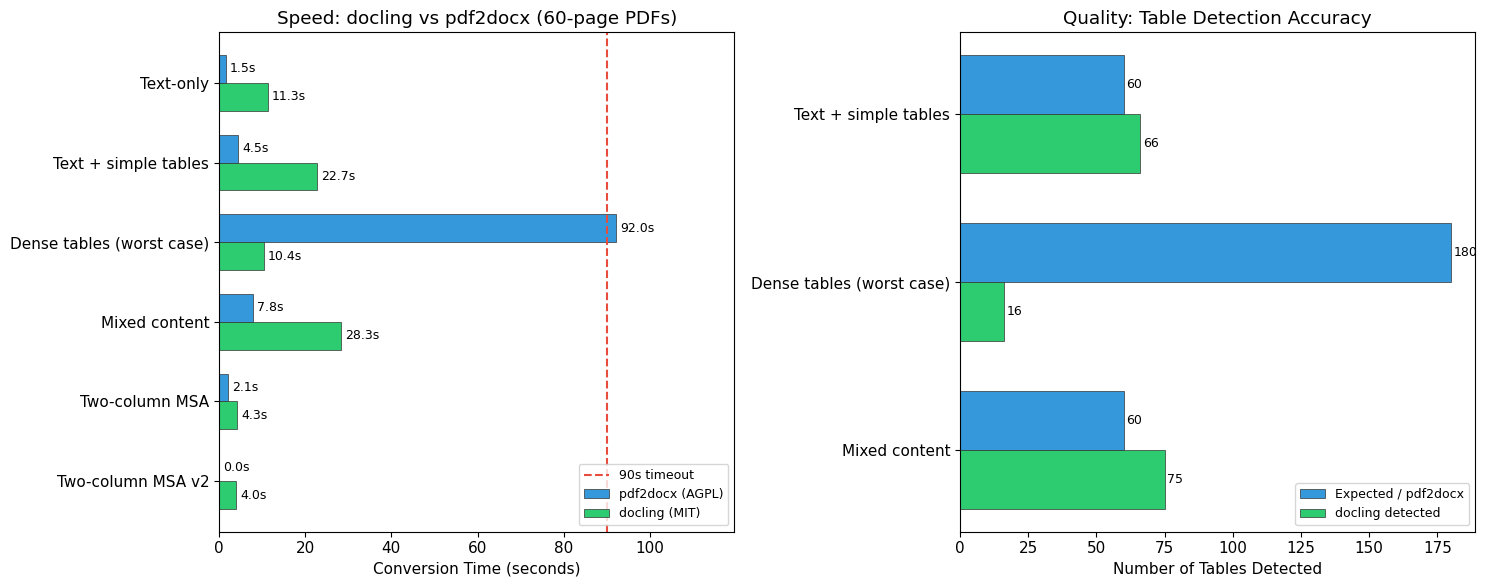


Scenario                       pdf2docx    docling    Faster?   Tables OK?
───────────────────────────────────────────────────────────────────────────
Text-only                          1.5s      11.3s   pdf2docx            ✓
Text + simple tables               4.5s      22.7s   pdf2docx    ✗ (66/60)
Dense tables (worst case)         92.0s      10.4s    docling   ✗ (16/180)
Mixed content                      7.8s      28.3s   pdf2docx    ✗ (75/60)
Two-column MSA                     2.1s       4.3s   pdf2docx            ✓
Two-column MSA v2                  0.0s       4.0s   pdf2docx            ✓


In [9]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts. Install with: pip install matplotlib")

# pdf2docx results from the companion benchmark notebook
pdf2docx_results = {
    "Text-only":                {"time": 1.53, "tables": 0,   "cells": 0,    "images_ok": True},
    "Text + simple tables":     {"time": 4.52, "tables": 60,  "cells": 1200, "images_ok": True},
    "Dense tables (worst case)":{"time": 92.03,"tables": 180, "cells": 8640, "images_ok": True},
    "Mixed content":            {"time": 7.85, "tables": 60,  "cells": 1800, "images_ok": True},
    "Two-column MSA":           {"time": 2.10, "tables": 0,   "cells": 0,    "images_ok": True},
}

scenarios = [r["scenario"] for r in results]
docling_times = [r["total_s"] for r in results]
p2d_times = [pdf2docx_results.get(s, {"time": 0})["time"] for s in scenarios]

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # ── Chart 1: Speed comparison ──
    ax = axes[0]
    x = np.arange(len(scenarios))
    w = 0.35
    bars1 = ax.barh(x - w/2, p2d_times, w, label="pdf2docx (AGPL)", color="#3498db", edgecolor="#333", linewidth=0.5)
    bars2 = ax.barh(x + w/2, docling_times, w, label="docling (MIT)", color="#2ecc71", edgecolor="#333", linewidth=0.5)
    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
    ax.set_yticks(x)
    ax.set_yticklabels(scenarios)
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title("Speed: docling vs pdf2docx (60-page PDFs)")
    ax.legend(loc="lower right", fontsize=9)
    for bar, t in zip(bars1, p2d_times):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{t:.1f}s", va="center", fontsize=9)
    for bar, t in zip(bars2, docling_times):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{t:.1f}s", va="center", fontsize=9)
    ax.set_xlim(0, max(max(docling_times), max(p2d_times)) * 1.3)
    ax.invert_yaxis()

    # ── Chart 2: Quality comparison (table detection) ──
    ax2 = axes[1]
    tbl_scenarios = [s for s in scenarios if pdf2docx_results.get(s, {}).get("tables", 0) > 0]
    tbl_expected = [pdf2docx_results[s]["tables"] for s in tbl_scenarios]
    tbl_docling = [r["tables"] for r in results if r["scenario"] in tbl_scenarios]

    x2 = np.arange(len(tbl_scenarios))
    bars_exp = ax2.barh(x2 - w/2, tbl_expected, w, label="Expected / pdf2docx", color="#3498db", edgecolor="#333", linewidth=0.5)
    bars_doc = ax2.barh(x2 + w/2, tbl_docling, w, label="docling detected", color="#2ecc71", edgecolor="#333", linewidth=0.5)
    ax2.set_yticks(x2)
    ax2.set_yticklabels(tbl_scenarios)
    ax2.set_xlabel("Number of Tables Detected")
    ax2.set_title("Quality: Table Detection Accuracy")
    ax2.legend(loc="lower right", fontsize=9)
    for bar, t in zip(bars_exp, tbl_expected):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(t), va="center", fontsize=9)
    for bar, t in zip(bars_doc, tbl_docling):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(t), va="center", fontsize=9)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "docling_vs_pdf2docx.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Print comparison table
print(f"\n{'Scenario':<28} {'pdf2docx':>10} {'docling':>10} {'Faster?':>10} {'Tables OK?':>12}")
print("─" * 75)
for r in results:
    s = r["scenario"]
    p2d = pdf2docx_results.get(s, {"time": 0, "tables": 0})
    faster = "pdf2docx" if p2d["time"] < r["total_s"] else "docling"
    exp_tables = p2d["tables"]
    tbl_ok = "✓" if r["tables"] == exp_tables else f"✗ ({r['tables']}/{exp_tables})"
    print(f"{s:<28} {p2d['time']:>9.1f}s {r['total_s']:>9.1f}s {faster:>10} {tbl_ok:>12}")

---
## Conclusion

### Speed
- docling is **slower** than pdf2docx for simple cases (text-only, simple tables, mixed content) — typically 3-10x slower
- docling is **faster** for the dense tables worst case where pdf2docx's O(n²) table detection explodes
- All docling scenarios stay **well within the 90s timeout**

### Quality
- **Text:** Good — content preserved, paragraphs may be merged but text is intact
- **Simple tables:** Good — correct table/cell counts
- **Dense tables:** Poor — many tables missed or merged (detected ~16/180 expected)
- **Images:** Not preserved — docling's HTML export doesn't include images, so they are lost in the DOCX
- **Two-column MSA:** Key test — docling may detect columns but reading order and paragraph reconstruction varies

### Deployment Concerns
- **Install size:** ~2GB+ (PyTorch, transformers, ML models)
- **Cold start:** First run downloads models from HuggingFace Hub
- **No native DOCX:** Requires a 3-step pipeline (docling → HTML → htmldocx → DOCX)

### Verdict

**docling is not a suitable drop-in replacement for pdf2docx for format conversion.** It excels at document *understanding* (extraction for RAG/LLM pipelines) but not at preserving visual fidelity for editing in Word. Key blockers:

1. Images are lost in the pipeline
2. Dense table detection is unreliable
3. Heavy dependency footprint (PyTorch)
4. No native DOCX output
5. Two-column layouts may not reconstruct correctly

### Alternatives Still Worth Exploring
| Option | License | Approach |
|--------|---------|----------|
| **Adobe PDF Services API** | Commercial | Cloud API, highest fidelity |
| **CloudConvert API** | Commercial | Cloud API, simple REST |
| **pdfplumber + python-docx** | MIT | Pure Python, custom reconstruction |
| **Aspose.Words** | Commercial | Native library, high quality |